In [ ]:
import numpy as np
import pandas as pd
from numba import njit, prange
from collections import Counter
import time

# Local Dynamics
@njit(parallel=False)
def fx(xold,yold,d):
    return (xold**2)*(np.exp(yold-xold))+d

@njit(parallel=False)
def fy(xold,yold,a,q,c):
    return a*(yold)-q*(xold)+c

@njit(parallel=False)
def xn(fxn, eps):
    return (1-eps)*fxn + eps*np.mean(fxn)    

@njit(parallel=True)
def GCM(eps, N, T, d, a, q, c):
    initialx = np.random.uniform(1, 3, N)
    initialy = np.random.uniform(1, 4, N)
    curr_x = initialx
    curr_y = initialy
    
    transient = T - 1000
    for t in range(transient):
        f_xj = fx(curr_x, curr_y, d)
        f_yj = fy(curr_x, curr_y, a, q, c)
        curr_x = xn(f_xj, eps)
        curr_y = f_yj
        
    # Save last 1000 steps
    b = 1000
    data_last = np.zeros((b, N))
    for t in range(b):
        data_last[t, :] = curr_x
        f_xj = fx(curr_x, curr_y, d)
        f_yj = fy(curr_x, curr_y, a, q, c)
        curr_x = xn(f_xj, eps)
        curr_y = f_yj
    return data_last

@njit
def fast_counting(connections, delta):
    counts = []
    current_cluster_len = 0
    for diff in connections:
        if diff <= delta:
            current_cluster_len += 1
        else:
            if current_cluster_len > 0:
                counts.append(current_cluster_len + 1) 
            current_cluster_len = 0
    if current_cluster_len > 0:
        counts.append(current_cluster_len + 1)
    return counts

# Parameters
N = 16000
T = 20000 
a, q, c = 0.89, 0.18, 0.28
EPSILONS = [0.15, 0.20, 0.25]
DELTA_FIJO = 10**-4
SIMULACIONES = 100

# Dictionary to save results
results_store = {}

print(f"--- STARTING DATA GENERATION (Simulations: {SIMULACIONES}) ---")
total_start = time.time()

for eps in EPSILONS:
    print(f"\nProcessing Epsilon = {eps}...")
    eps_counter = Counter()
    start_eps = time.time()
    
    for i in range(SIMULACIONES):
        noise = np.random.uniform(0.026, 0.03, N)
        d = noise
        
        # Correr dinámica
        data_last = GCM(eps, N, T, d, a, q, c)
        
        # Análisis
        batch_clusters = []
        for t_idx in range(data_last.shape[0]):
            row_sorted = np.sort(data_last[t_idx])
            diffs = np.diff(row_sorted) 
            clusters = fast_counting(diffs, DELTA_FIJO)
            batch_clusters.extend(clusters)
        
        eps_counter.update(batch_clusters)
        
        if (i+1) % 10 == 0:
            print(f"  Simulation {i+1}/{SIMULACIONES} ok.")
            
    results_store[eps] = eps_counter
    print(f"  -> Epsilon {eps} finished in {time.time()-start_eps:.1f}s")

print(f"\nData generated in {time.time()-total_start:.1f}s")

# Save data
print("Saving data in your file...")
df = pd.DataFrame.from_dict(results_store, orient='index').T.sort_index()
df.index.name = 'cluster_size'
df = df.fillna(0) 
df.to_csv('griffiths_data.csv')
print("Saved successfully!")


--- INICIANDO GENERACIÓN DE DATA (Simulaciones: 100) ---

Procesando Epsilon = 0.15...
  Simulacion 10/100 ok.
  Simulacion 20/100 ok.
  Simulacion 30/100 ok.
  Simulacion 40/100 ok.
  Simulacion 50/100 ok.
  Simulacion 60/100 ok.
  Simulacion 70/100 ok.
  Simulacion 80/100 ok.
  Simulacion 90/100 ok.
  Simulacion 100/100 ok.
  -> Epsilon 0.15 terminado en 1629.7s

Procesando Epsilon = 0.2...
  Simulacion 10/100 ok.
  Simulacion 20/100 ok.
  Simulacion 30/100 ok.
  Simulacion 40/100 ok.
  Simulacion 50/100 ok.
  Simulacion 60/100 ok.
  Simulacion 70/100 ok.
  Simulacion 80/100 ok.
  Simulacion 90/100 ok.
  Simulacion 100/100 ok.
  -> Epsilon 0.2 terminado en 1216.7s

Procesando Epsilon = 0.25...
  Simulacion 10/100 ok.
  Simulacion 20/100 ok.
  Simulacion 30/100 ok.
  Simulacion 40/100 ok.
  Simulacion 50/100 ok.
  Simulacion 60/100 ok.
  Simulacion 70/100 ok.
  Simulacion 80/100 ok.
  Simulacion 90/100 ok.
  Simulacion 100/100 ok.
  -> Epsilon 0.25 terminado en 1235.7s

Data generada 

Loading data...
Data loaded correctly.


C:\Users\juanc\AppData\Local\Temp\ipykernel_32648\3819542761.py:66: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 10000)


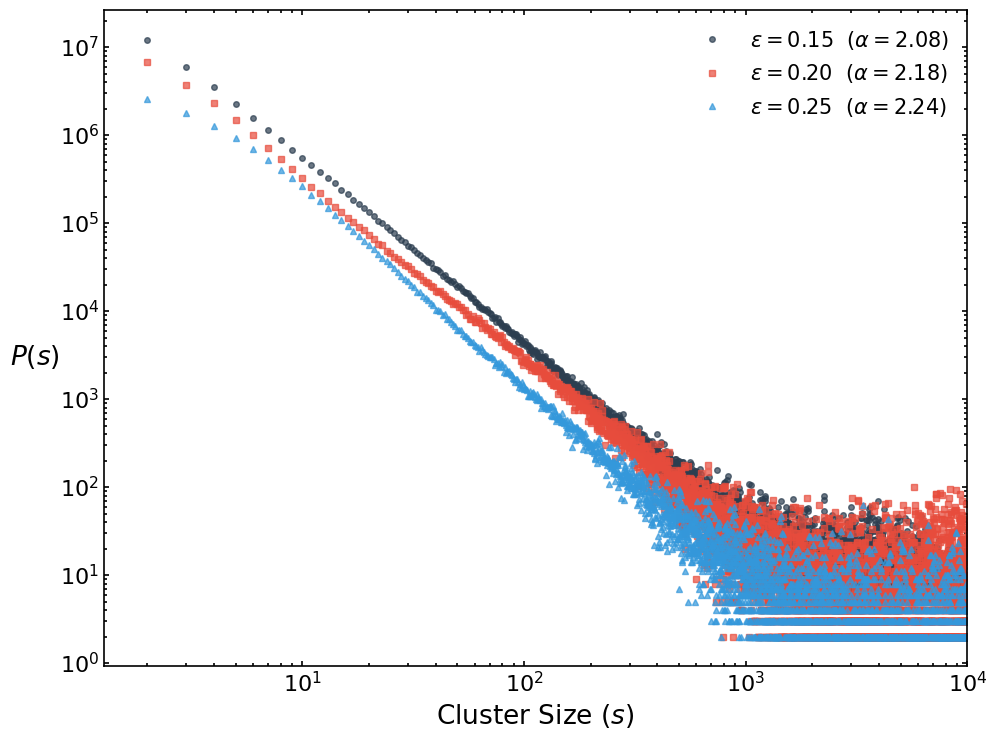

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Import data
print("Loading data...")
try:
    df = pd.read_csv('griffiths_data.csv', index_col='cluster_size')
    print("Data loaded correctly.")
except FileNotFoundError:
    print("There is no your data file.")
    raise

FLOOR = 2  # Optional Filter for bottom of the distribution

# Optional to improve fit
FIT_MIN = 10  
FIT_MAX = 1000 

# Function to calculate slope
def get_power_law_alpha(x, y, x_min, x_max):
    # Filter fit range
    mask = (x >= x_min) & (x <= x_max) & (y > 0)
    x_fit = x[mask]
    y_fit = y[mask]
    
    if len(x_fit) < 2: return 0.0
    
    # Linear fit in log-log scale
    log_x = np.log10(x_fit)
    log_y = np.log10(y_fit)
    
    slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)
    return np.abs(slope), r_value**2

# Plot
colors = {0.15: '#2c3e50', 0.20: '#e74c3c', 0.25: '#3498db'} 
markers = {0.15: 'o', 0.20: 's', 0.25: '^'} 
plt.figure(figsize=(10, 7.5))

# Iterate over columns
for eps_col in df.columns:
    eps = float(eps_col)
    x_val = df.index.values
    y_val = df[eps_col].values
    
    # Apply optional filter
    mask_floor = y_val >= FLOOR
    x_plot = x_val[mask_floor]
    y_plot = y_val[mask_floor]    
    if len(x_plot) == 0: continue

    # Calculate slope
    alpha, r2 = get_power_law_alpha(x_val, y_val, FIT_MIN, FIT_MAX)
    label_txt = f'$\\epsilon={eps:.2f}$  ($\\alpha={alpha:.2f}$)'
    
    plt.loglog(x_plot, y_plot, 
               linestyle='none', 
               marker=markers.get(eps, 'o'), 
               markersize=4, 
               color=colors.get(eps, 'k'), 
               alpha=0.7, 
               label=label_txt)
    
plt.xlim(0, 10000) 
plt.xlabel(r'Cluster Size ($s$)', fontsize=19)
plt.ylabel(r'$P(s)$', fontsize=19, rotation=0)

legend = plt.legend(fontsize=15, frameon=False, fancybox=False, edgecolor='black', loc='upper right')
legend.get_frame().set_linewidth(1.0)

plt.grid(False) 
ax = plt.gca()
ax.spines['top'].set_linewidth(1.2)
ax.spines['right'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)
ax.tick_params(width=1.2, which='both',labelsize=16, direction='in', top=True, right=True)
ax.yaxis.set_label_coords(-0.08, 0.45)
plt.tight_layout()
filename = 'Fig5_Power_Law.pdf'
plt.savefig(filename, format='pdf', dpi=300, bbox_inches="tight")
plt.show()